# Functional Mapping (FM) Pipeline
This pipeline automates the transition from raw connectome data to high-dimensional functional activity maps. It quantifies how signals from specific sensory inputs propagate through the neural network across both brain hemispheres.

**Core Workflow:**

**Matrix Exporting:** Converts raw connection lists into compressed sparse matrices for high-performance computing.

**Functional Analysis:** Computes multi-step synaptic influence weights based on network topology, depth, and pruning thresholds.

**Visual Preprocessing:** Maps abstract neuronal weights onto biological spatial coordinates (columns) for anatomical visualization.

In [2]:
# -----------------------------
# 1. ENVIRONMENT SETUP
# -----------------------------
import sys
import os

sys.path.append(os.path.abspath('../util'))

from connectome_matrix import ConnectomeMatrixExporter
from FM_analyzer import FMAnalyzer
from show_VFM import VFMShow

In [ ]:
# -----------------------------
# 2. DATA EXPORTING
# -----------------------------
# Initialized to convert raw connection files into Connectome Matrix
exporter = ConnectomeMatrixExporter(
        connections_path="../data/connections.txt",
        n_jobs=128,
        results_dir="output"
    )

exporter.save_connectome_matrix_npy()

In [ ]:
# -----------------------------
# 3. FUNCTIONAL WEIGHT COMPUTATION
# -----------------------------
# Configures the analyzer with exported matrices and neuron metadata
analyzer = FMAnalyzer(
    matrix_npz_path="./output/connectome_matrix.npz",
    neuron_ids_path="./output/neuron_ids.npy",
    neuron_types_path="../data/visual_neuron_types.txt"
)

params_right = {
    'neuron_types': {'L1','L2','L3'},   
    'side': 'right',                      
    'max_depth': 100,                     
    'min_weight': 1e-8,                   
    'num_processes': 100,                  
    'blocked_types': []       
}

params_left = {
    'neuron_types': {'L1','L2','L3'},   
    'side': 'left',                      
    'max_depth': 100,                     
    'min_weight': 1e-8,                   
    'num_processes': 100,                  
    'blocked_types': []       
}

# Independently compute functional maps for Right and Left brain hemispheres
analyzer.compute_and_save_weights(**params_left)
analyzer.compute_and_save_weights(**params_right)


In [ ]:
# -----------------------------
# 4. VISUALIZATION PREPROCESSING
# -----------------------------

vfm_show = VFMShow("../data/column_assignment.txt")

# preprocess the neuron matrices for visualization
vfm_show.generate_all_matrices(
    neuron_types=['L1','L2','L3'],
    side="right",
    blocked_types=[],
)

vfm_show.generate_all_matrices(
    neuron_types=['L1','L2','L3'],
    side="left",
    blocked_types=[],
)


Processing all layers for right hemisphere (PyTorch accelerated)...
Using device: cuda

Processing layer l1...

Processing layer l2...

Processing layer l3...

Saving output...
All raster matrices saved (no centering).

Processing all layers for left hemisphere (PyTorch accelerated)...
Using device: cuda

Processing layer l1...

Processing layer l2...

Processing layer l3...

Saving output...
All raster matrices saved (no centering).


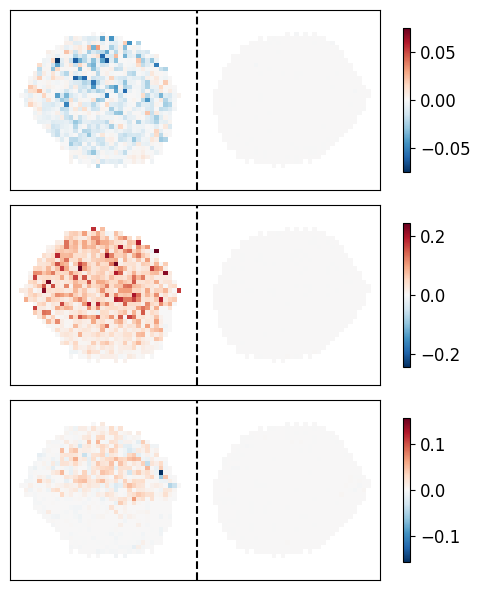

In [4]:
vfm_show = VFMShow("../data/column_assignment.txt")

neuron_ids = [720575940622838154]
for neuron_id in neuron_ids:
    
    vfm_show.plot_single_neuron_all_layers(neuron_id=neuron_id, normalize=True)